# ĐÁP ÁN — Bài kiểm tra Lập trình phân tích dữ liệu · Buổi 1–5 (60 phút) · Đề số 02
Notebook tham chiếu cho giảng viên. Các con số in ra ở mỗi ô là **kết quả chuẩn** để đối chiếu bài làm.
Bối cảnh: EcoRide — dịch vụ cho thuê xe đạp và xe điện công cộng tại Đà Nẵng và Hội An.

In [1]:
import re
import sqlite3
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

DATA_DIR = Path('../du_lieu')

## Phần A — Python thuần: tập tin văn bản, regex, hàm (2,0 điểm)
### A1 (1,0 đ) Lọc dòng hợp lệ bằng regex, ghi dòng lỗi ra file

In [2]:
MAU = re.compile(r'(\d{4}-\d{2}-\d{2}) (\d{2}:\d{2}) \| ((?:DN|HA)\d{2}) \| (X[DM]\d{3}) '
                 r'\| (MUON|TRA) \| pin=(\d{1,3})%')

hop_le, loi = [], []
with open(DATA_DIR / 'nhat_ky_khoa_xe.txt', encoding='utf-8') as f:
    for dong in f:
        dong = dong.rstrip('\n')
        if dong.strip() == '' or dong.startswith('#'):
            continue
        (hop_le if MAU.fullmatch(dong) else loi).append(dong)

with open('dong_loi.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(loi) + '\n')

print('Số dòng hợp lệ      :', len(hop_le))
print('Số dòng không hợp lệ:', len(loi))
dem_tram = Counter(MAU.fullmatch(d).group(3) for d in hop_le)
print('Số sự kiện theo trạm:', dict(sorted(dem_tram.items())))

# Kiểm tra bẫy
print('Nếu dùng re.match (không khớp hết dòng):', sum(bool(MAU.match(d)) for d in hop_le + loi))

Số dòng hợp lệ      : 754
Số dòng không hợp lệ: 48
Số sự kiện theo trạm: {'DN01': 132, 'DN02': 135, 'DN03': 119, 'DN04': 122, 'HA01': 136, 'HA02': 110}
Nếu dùng re.match (không khớp hết dòng): 762


### A2 (1,0 đ) Hàm thống kê pin yếu & tập thành phố

In [3]:
def ti_le_pin_yeu(cac_dong, nguong=20, toi_thieu=8):
    so_tra, so_yeu = Counter(), Counter()
    for d in cac_dong:
        _, _, _, xe, su_kien, pin = MAU.fullmatch(d).groups()
        if su_kien != 'TRA':
            continue
        so_tra[xe] += 1
        if int(pin) < nguong:
            so_yeu[xe] += 1
    return {xe: so_yeu[xe] / n for xe, n in so_tra.items() if n >= toi_thieu}


kq = ti_le_pin_yeu(hop_le)
for xe in sorted(kq):
    print(f'{xe}: {kq[xe]:.3f}')
xe_max = max(kq, key=kq.get)
print(f'\nTỉ lệ pin yếu cao nhất (>= 8 lần trả): {xe_max} — {kq[xe_max]:.1%}')

thanh_pho = {}
for d in hop_le:
    _, _, tram, xe, *_ = MAU.fullmatch(d).groups()
    thanh_pho.setdefault(xe, set()).add(tram[:2])
print('Có sự kiện ở cả Đà Nẵng và Hội An:', sorted(xe for xe, s in thanh_pho.items() if s == {'DN', 'HA'}))

# Kiểm tra bẫy
tat_ca = ti_le_pin_yeu(hop_le, toi_thieu=0)
print('Bị loại vì < 8 lần trả:', {xe: f'{v:.1%}' for xe, v in tat_ca.items() if xe not in kq})
sai_bien = ti_le_pin_yeu(hop_le, nguong=21)
print('Nếu tính pin yếu khi <= 20%:', max(sai_bien, key=sai_bien.get), f'{max(sai_bien.values()):.3f}')
dem_ca_muon = Counter()
for d in hop_le:
    dem_ca_muon[MAU.fullmatch(d).group(4)] += 1
print('Nếu quên lọc TRA (đếm cả MUON):', {xe: n for xe, n in dem_ca_muon.items() if xe in ('XM003', 'XD007', 'XM010')})

XD001: 0.118
XD002: 0.062
XD003: 0.211
XD004: 0.231
XD005: 0.077
XD006: 0.062
XD007: 0.318
XD008: 0.000
XD009: 0.158
XD010: 0.053
XD011: 0.059
XD012: 0.250
XD013: 0.000
XD014: 0.214
XM001: 0.062
XM002: 0.167
XM003: 0.350
XM004: 0.100
XM005: 0.118
XM006: 0.133
XM007: 0.000
XM008: 0.167
XM009: 0.250

Tỉ lệ pin yếu cao nhất (>= 8 lần trả): XM003 — 35.0%
Có sự kiện ở cả Đà Nẵng và Hội An: ['XD004', 'XD012', 'XM008', 'XM010']
Bị loại vì < 8 lần trả: {'XM010': '80.0%'}
Nếu tính pin yếu khi <= 20%: XD007 0.500
Nếu quên lọc TRA (đếm cả MUON): {'XM003': 40, 'XD007': 44, 'XM010': 10}


## Phần B — NumPy & lập trình hướng đối tượng (2,0 điểm)
### B1 (0,5 đ) Ma trận lượt thuê trạm × khung giờ

In [4]:
L = np.array([[42, 35, 28, 39, 71],
              [58, 31, 22, 34, 66],
              [25, 47, 44, 41, 52],
              [18, 26, 19, 23, 37],
              [12, 38, 41, 45, 83],
              [33, 29, 24, 36, 48]])
TRAM = ['DN01', 'DN02', 'DN03', 'DN04', 'HA01', 'HA02']
KHUNG = ['05–08h', '08–11h', '11–14h', '14–17h', '17–20h']

tong_tram = L.sum(axis=1)
print('Tổng lượt theo trạm:', tong_tram, '→ cao nhất:', TRAM[tong_tram.argmax()])
tb_khung = L.mean(axis=0)
print('TB theo khung giờ:', tb_khung.round(2), '→ cao nhất:', KHUNG[tb_khung.argmax()])
ty_trong = L / L.sum(axis=1, keepdims=True)
cao_diem = ty_trong[:, [0, 4]].sum(axis=1)
print('Tỉ trọng cao điểm (05–08h + 17–20h):', cao_diem.round(3))
print('Trạm có tỉ trọng cao điểm > 0,5:', np.array(TRAM)[cao_diem > 0.5])
print('Số ô lớn hơn TB của chính khung giờ đó:', (L > L.mean(axis=0)).sum())
print('Bẫy — so với TB theo trạm (axis=1):', (L > L.mean(axis=1, keepdims=True)).sum(),
      '· so với TB toàn ma trận:', (L > L.mean()).sum())

Tổng lượt theo trạm: [215 211 209 123 219 170] → cao nhất: HA01
TB theo khung giờ: [31.33 34.33 29.67 36.33 59.5 ] → cao nhất: 17–20h
Tỉ trọng cao điểm (05–08h + 17–20h): [0.526 0.588 0.368 0.447 0.434 0.476]
Trạm có tỉ trọng cao điểm > 0,5: ['DN01' 'DN02']
Số ô lớn hơn TB của chính khung giờ đó: 14
Bẫy — so với TB theo trạm (axis=1): 12 · so với TB toàn ma trận: 13


### B2 (0,5 đ) Giải hệ phương trình tìm bảng giá

In [5]:
A = np.array([[1, 20, 3],
              [1, 35, 8],
              [1, 50, 9]])
b = np.array([23, 42, 53])
x = np.linalg.solve(A, b)
print('Phí mở khoá, giá mỗi phút, phụ phí mỗi km (nghìn đồng) =', x)
print('det(A) =', round(np.linalg.det(A), 2), '· kiểm tra A @ x == b:', np.allclose(A @ x, b))
print('Dự đoán chuyến 30 phút, 6 km:', np.array([1, 30, 6]) @ x, 'nghìn đồng')

Phí mở khoá, giá mỗi phút, phụ phí mỗi km (nghìn đồng) = [5.  0.6 2. ]
det(A) = -60.0 · kiểm tra A @ x == b: True
Dự đoán chuyến 30 phút, 6 km: 35.0 nghìn đồng


### B3 (1,0 đ) Lớp ChuyenDi và ChuyenDiGoiThang

In [6]:
class ChuyenDi:
    PHI_MO_KHOA = 5000

    def __init__(self, ma, phut, km, gia_phut):
        self.ma, self.km, self.gia_phut = ma, km, gia_phut
        self.phut = phut

    @property
    def phut(self):
        return self._phut

    @phut.setter
    def phut(self, gia_tri):
        if gia_tri <= 0:
            raise ValueError(f'{self.ma}: thời lượng {gia_tri} phút không hợp lệ')
        self._phut = gia_tri

    def cuoc_phi(self):
        return self.PHI_MO_KHOA + self.phut * self.gia_phut

    def toc_do_tb(self):
        return self.km / (self.phut / 60)

    def __str__(self):
        return (f'{self.ma}: {self.phut} phút · {self.km:.1f} km · '
                f'{self.toc_do_tb():.1f} km/h · cước {self.cuoc_phi():,.0f}đ')


class ChuyenDiGoiThang(ChuyenDi):
    def __init__(self, ma, phut, km, gia_phut, phut_mien_phi=30):
        super().__init__(ma, phut, km, gia_phut)
        self.phut_mien_phi = phut_mien_phi

    def cuoc_phi(self):
        return max(0, self.phut - self.phut_mien_phi) * self.gia_phut


cd1 = ChuyenDi('CD001', 25, 6.0, 500)
cd2 = ChuyenDiGoiThang('CD002', 48, 10.4, 500)
print(cd1)
print(cd2)
try:
    cd1.phut = 0
except ValueError as e:
    print('Lỗi:', e)

CD001: 25 phút · 6.0 km · 14.4 km/h · cước 17,500đ
CD002: 48 phút · 10.4 km · 13.0 km/h · cước 9,000đ
Lỗi: CD001: thời lượng 0 phút không hợp lệ


## Phần C — Pandas: đọc, làm sạch, tích hợp (2,5 điểm)
### C1 (0,5 đ) Đọc dữ liệu từ CSV, Excel và SQLite

In [7]:
cd = pd.read_csv(DATA_DIR / 'chuyen_di.csv')
for cot in ['bat_dau', 'ket_thuc']:
    cd[cot] = pd.to_datetime(cd[cot], format='%d/%m/%Y %H:%M')
kh = pd.read_excel(DATA_DIR / 'khach_hang.xlsx', sheet_name='khach_hang', dtype={'so_dien_thoai': str})
goi = pd.read_excel(DATA_DIR / 'khach_hang.xlsx', sheet_name='goi_cuoc')
with sqlite3.connect(DATA_DIR / 'he_thong.db') as con:
    tram = pd.read_sql('SELECT * FROM tram', con)
    loai = pd.read_sql('SELECT * FROM loai_xe', con)

for ten, bang in [('chuyen_di', cd), ('khach_hang', kh), ('goi_cuoc', goi), ('tram', tram), ('loai_xe', loai)]:
    print(f'{ten:11}: {bang.shape}')
print('\nGiá trị thiếu trong chuyen_di:')
print(cd.isna().sum()[lambda s: s > 0])

chuyen_di  : (2635, 9)
khach_hang : (508, 5)
goi_cuoc   : (3, 2)
tram       : (6, 4)
loai_xe    : (3, 5)

Giá trị thiếu trong chuyen_di:
ket_thuc           48
ma_kh             913
quang_duong_km     40
danh_gia          559
dtype: int64


### C2 (1,0 đ) Làm sạch bảng chuyến đi theo đúng 5 bước

In [8]:
n0 = len(cd)
cd = cd.drop_duplicates()                                                    # 1
n1 = len(cd)

CHUAN_LOAI = {'xe đạp': 'Xe đạp', 'xe dap': 'Xe đạp',                        # 2
              'xe đạp điện': 'Xe đạp điện', 'xe dap dien': 'Xe đạp điện',
              'xe máy điện': 'Xe máy điện', 'xe may dien': 'Xe máy điện'}
cd['loai_xe'] = cd['loai_xe'].str.strip().str.lower().map(CHUAN_LOAI)

cd['phut'] = (cd['ket_thuc'] - cd['bat_dau']).dt.total_seconds() / 60       # 3
so_am = (cd['phut'] <= 0).sum()
cd.loc[cd['phut'] <= 0, 'phut'] = np.nan
cd = cd[~(cd['phut'] < 2)]
n3 = len(cd)

sai_gps = (cd['quang_duong_km'] < 0) | (cd['quang_duong_km'] > 80)           # 4
so_gps = sai_gps.sum()
cd.loc[sai_gps, 'quang_duong_km'] = np.nan

q1 = cd.groupby('loai_xe')['phut'].transform(lambda s: s.quantile(0.25))     # 5
q3 = cd.groupby('loai_xe')['phut'].transform(lambda s: s.quantile(0.75))
tren = q3 + 1.5 * (q3 - q1)
ngoai_lai = cd['phut'] > tren
print('Ngưỡng trên theo loại xe:', (cd.assign(tren=tren).groupby('loai_xe')['tren'].first()).round(2).to_dict())
print('Ngoại lai theo loại xe:', cd.loc[ngoai_lai, 'loai_xe'].value_counts().to_dict())
q1c, q3c = cd['phut'].quantile([0.25, 0.75])                                 # bẫy: IQR chung cả cột
print('Nếu dùng IQR chung (ngưỡng %.1f phút):' % (q3c + 1.5 * (q3c - q1c)),
      cd.loc[cd['phut'] > q3c + 1.5 * (q3c - q1c), 'loai_xe'].value_counts().to_dict())
cd['phut'] = cd['phut'].clip(upper=tren)
for cot in ['phut', 'quang_duong_km']:
    cd[cot] = cd[cot].fillna(cd.groupby('loai_xe')[cot].transform('median'))

print('Ban đầu:', n0, '· sau bước 1:', n1, f'(bỏ {n0 - n1})', '· sau bước 3:', n3, f'(bỏ {n1 - n3})')
print('Số chuyến theo loại xe:', cd['loai_xe'].value_counts().to_dict())
print('phut <= 0 → NaN:', so_am, '· GPS lỗi → NaN:', so_gps)
print('Trung vị phut theo loại xe:', cd.groupby('loai_xe')['phut'].median().to_dict())
print('Còn thiếu:', cd[['phut', 'quang_duong_km', 'loai_xe']].isna().sum().to_dict())

Ngưỡng trên theo loại xe: {'Xe máy điện': 96.0, 'Xe đạp': 44.5, 'Xe đạp điện': 57.0}
Ngoại lai theo loại xe: {'Xe đạp điện': 37, 'Xe đạp': 31, 'Xe máy điện': 23}
Nếu dùng IQR chung (ngưỡng 66.0 phút): {'Xe máy điện': 103, 'Xe đạp điện': 26, 'Xe đạp': 5}
Ban đầu: 2635 · sau bước 1: 2600 (bỏ 35) · sau bước 3: 2573 (bỏ 27)
Số chuyến theo loại xe: {'Xe đạp điện': 976, 'Xe đạp': 881, 'Xe máy điện': 716}
phut <= 0 → NaN: 9 · GPS lỗi → NaN: 11
Trung vị phut theo loại xe: {'Xe máy điện': 37.0, 'Xe đạp': 17.0, 'Xe đạp điện': 24.0}
Còn thiếu: {'phut': 0, 'quang_duong_km': 0, 'loai_xe': 0}


### C3 (1,0 đ) Tích hợp bốn nguồn

In [9]:
print('gia_30_phut là cột dẫn xuất:', (loai['gia_30_phut'] == loai['phi_mo_khoa'] + 30 * loai['gia_phut']).all())
loai = loai.drop(columns='gia_30_phut')

print('Mã khách trùng:', kh['ma_kh'].duplicated().sum(), '· dòng trùng hoàn toàn:', kh.duplicated().sum())
kh = kh.drop_duplicates(subset='ma_kh')
so = kh['so_dien_thoai'].str.replace(r'\D', '', regex=True).str.replace(r'^84', '0', regex=True)
kh['so_dien_thoai'] = so
print('Số điện thoại không đủ 10 chữ số:', (so.str.len() != 10).sum())
kh = kh.merge(goi, on='goi_cuoc', how='left')
print('Số khách theo gói:', kh['goi_cuoc'].value_counts().to_dict())

ngoai_danh_muc = ~cd['tram_muon'].isin(tram['id'])
print('Chuyến có tram_muon ngoài danh mục:', ngoai_danh_muc.sum(), cd.loc[ngoai_danh_muc, 'tram_muon'].unique().tolist())
df = (cd[~ngoai_danh_muc]
      .merge(loai, left_on='loai_xe', right_on='ten_loai', how='left', validate='many_to_one')
      .merge(kh[['ma_kh', 'goi_cuoc', 'giam_gia']], on='ma_kh', how='left', validate='many_to_one')
      .merge(tram, left_on='tram_muon', right_on='id', how='left', validate='many_to_one')
      .drop(columns=['ten_loai', 'id']))
df['goi_cuoc'] = df['goi_cuoc'].fillna('Khách lẻ')
df['giam_gia'] = df['giam_gia'].fillna(0)
df['cuoc'] = df['phi_mo_khoa'] + df['phut'] * df['gia_phut']
df['doanh_thu'] = df['cuoc'] * (1 - df['giam_gia'])

print('\nSố dòng df:', len(df), '· khách lẻ:', (df['goi_cuoc'] == 'Khách lẻ').sum())
print(f'Tổng doanh thu: {df["doanh_thu"].sum():,.0f}')
print((df.groupby('thanh_pho')['doanh_thu'].sum() / 1e6).round(1).sort_values(ascending=False))
print((df.groupby('ten_tram')['doanh_thu'].sum() / 1e6).round(1).sort_values(ascending=False))

gia_30_phut là cột dẫn xuất: True
Mã khách trùng: 8 · dòng trùng hoàn toàn: 3
Số điện thoại không đủ 10 chữ số: 9
Số khách theo gói: {'Tiêu chuẩn': 261, 'Sinh viên': 156, 'Thân thiết': 83}
Chuyến có tram_muon ngoài danh mục: 24 ['DN07']

Số dòng df: 2549 · khách lẻ: 918
Tổng doanh thu: 55,701,300
thanh_pho
Đà Nẵng    33.3
Hội An     22.4
Name: doanh_thu, dtype: float64
ten_tram
Phố cổ      13.6
Cầu Rồng    11.3
Mỹ Khê       9.1
An Bàng      8.8
Chợ Hàn      8.0
Sơn Trà      4.9
Name: doanh_thu, dtype: float64


## Phần D — Biến đổi & thu gọn dữ liệu (1,5 điểm)
### D1 (0,75 đ) Biến đổi

In [10]:
THU_TU = {'Rất không hài lòng': 1, 'Không hài lòng': 2, 'Bình thường': 3, 'Hài lòng': 4, 'Rất hài lòng': 5}
df['diem_dg'] = df['danh_gia'].map(THU_TU)
mode_dg = df['diem_dg'].mode()[0]
df['diem_dg'] = df['diem_dg'].fillna(mode_dg).astype(int)
print('Mode:', mode_dg, '· phân bố:', df['diem_dg'].value_counts().sort_index().to_dict())

df['log_phut'] = np.log1p(df['phut'])
print('Skew phut:', round(st.skew(df['phut']), 3), '→ sau log1p:', round(st.skew(df['log_phut']), 3))

KHUNG_GIO = ['Sáng', 'Trưa chiều', 'Tan tầm', 'Tối']
df['khung_gio'] = pd.cut(df['bat_dau'].dt.hour, bins=[0, 9, 16, 20, 24], right=False, labels=KHUNG_GIO)
print('Số chuyến theo khung giờ:', df['khung_gio'].value_counts(sort=False).to_dict())
sai = pd.cut(df['bat_dau'].dt.hour, bins=[0, 9, 16, 20, 24], labels=KHUNG_GIO)
print('Bẫy — quên right=False:', sai.value_counts(sort=False, dropna=False).to_dict())
dummy = pd.get_dummies(df['khung_gio'], prefix='kg', dtype=int)
print('One-hot:', dummy.columns.tolist(), dummy.sum().to_dict())

Mode: 4.0 · phân bố: {1: 2, 2: 95, 3: 520, 4: 1464, 5: 468}
Skew phut: 1.491 → sau log1p: 0.02
Số chuyến theo khung giờ: {'Sáng': 718, 'Trưa chiều': 759, 'Tan tầm': 867, 'Tối': 205}
Bẫy — quên right=False: {'Sáng': 825, 'Trưa chiều': 844, 'Tan tầm': 779, 'Tối': 101}
One-hot: ['kg_Sáng', 'kg_Trưa chiều', 'kg_Tan tầm', 'kg_Tối'] {'kg_Sáng': 718, 'kg_Trưa chiều': 759, 'kg_Tan tầm': 867, 'kg_Tối': 205}


### D2 (0,75 đ) Tổng hợp theo khách hàng & giảm chiều

In [11]:
thanh_vien = df[df['goi_cuoc'] != 'Khách lẻ']
khach = thanh_vien.groupby('ma_kh').agg(
    so_chuyen=('ma_cd', 'count'),
    tong_chi=('doanh_thu', 'sum'),
    phut_tb=('phut', 'mean'),
    km_tb=('quang_duong_km', 'mean'),
    diem_tb=('diem_dg', 'mean'),
    ti_le_xe_may=('loai_xe', lambda s: (s == 'Xe máy điện').mean()),
)
khach['tong_chi'] = khach['tong_chi'] / 1e3
print('Bảng khách:', khach.shape)
khach['nhom_chi'] = pd.qcut(khach['tong_chi'], q=4, labels=['Thấp', 'Trung bình', 'Khá', 'Cao'])
print('Nhóm chi tiêu:', khach['nhom_chi'].value_counts(sort=False).to_dict())

so_ = khach.drop(columns='nhom_chi')
tq = so_.corr()
print(tq.round(2))
cap = [(a, b_, round(tq.loc[a, b_], 2)) for i, a in enumerate(tq.columns) for b_ in tq.columns[i + 1:]
       if abs(tq.loc[a, b_]) > 0.7]
print('Cặp |r| > 0.7:', cap)

Z = StandardScaler().fit_transform(so_)
pca = PCA(n_components=0.9).fit(Z)
print('PCA giữ >= 90%:', pca.n_components_, 'thành phần ·', PCA().fit(Z).explained_variance_ratio_.cumsum().round(3))
print('Bẫy — không chuẩn hoá:', PCA(n_components=0.9).fit(so_).n_components_, 'thành phần ·',
      PCA().fit(so_).explained_variance_ratio_.cumsum().round(3))

Bảng khách: (474, 6)
Nhóm chi tiêu: {'Thấp': 120, 'Trung bình': 117, 'Khá': 118, 'Cao': 119}
              so_chuyen  tong_chi  phut_tb  km_tb  diem_tb  ti_le_xe_may
so_chuyen          1.00      0.78     0.15   0.14     0.02          0.10
tong_chi           0.78      1.00     0.54   0.58     0.13          0.48
phut_tb            0.15      0.54     1.00   0.91     0.13          0.48
km_tb              0.14      0.58     0.91   1.00     0.16          0.63
diem_tb            0.02      0.13     0.13   0.16     1.00          0.26
ti_le_xe_may       0.10      0.48     0.48   0.63     0.26          1.00
Cặp |r| > 0.7: [('so_chuyen', 'tong_chi', np.float64(0.78)), ('phut_tb', 'km_tb', np.float64(0.91))]


PCA giữ >= 90%: 4 thành phần · [0.508 0.725 0.885 0.973 0.988 1.   ]
Bẫy — không chuẩn hoá: 1 thành phần · [0.98  0.999 1.    1.    1.    1.   ]


## Phần E — Trực quan hoá (2,0 điểm)

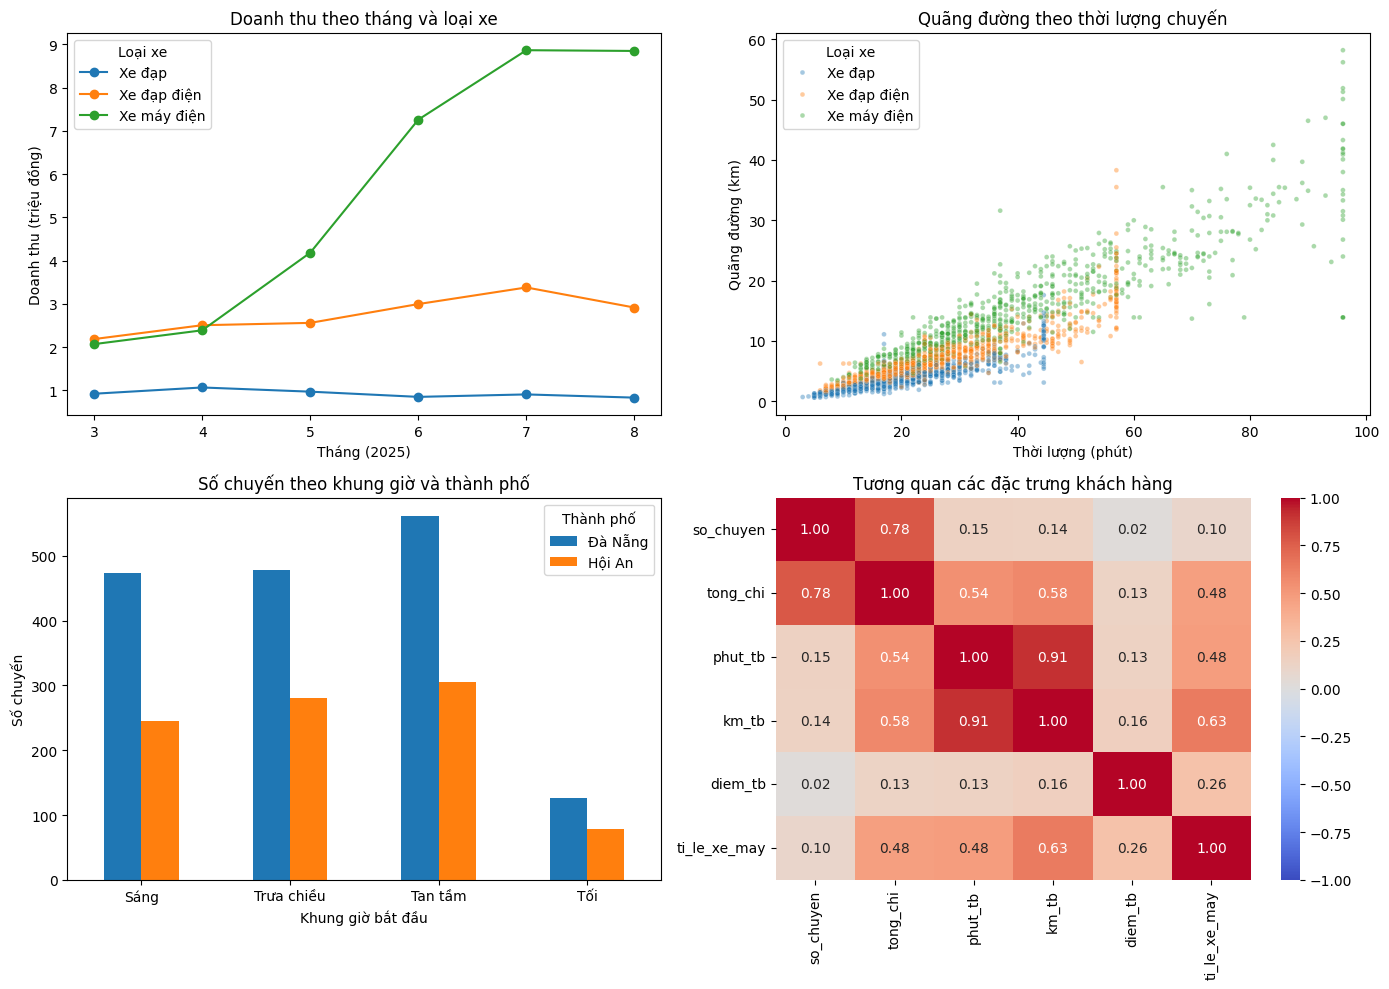

loai_xe  Xe đạp  Xe đạp điện  Xe máy điện
bat_dau                                  
3           0.9          2.2          2.1
4           1.1          2.5          2.4
5           1.0          2.6          4.2
6           0.8          3.0          7.3
7           0.9          3.4          8.9
8           0.8          2.9          8.8
thanh_pho   Đà Nẵng  Hội An
khung_gio                  
Sáng            473     245
Trưa chiều      478     281
Tan tầm         562     305
Tối             126      79


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

THU_TU_XE = ['Xe đạp', 'Xe đạp điện', 'Xe máy điện']
theo_thang = (df.groupby([df['bat_dau'].dt.month, 'loai_xe'])['doanh_thu'].sum() / 1e6).unstack()[THU_TU_XE]
theo_thang.plot(ax=axes[0, 0], marker='o')
axes[0, 0].set(title='Doanh thu theo tháng và loại xe', xlabel='Tháng (2025)', ylabel='Doanh thu (triệu đồng)')
axes[0, 0].legend(title='Loại xe')

sns.scatterplot(data=df, x='phut', y='quang_duong_km', hue='loai_xe', hue_order=THU_TU_XE, alpha=0.4, s=12, ax=axes[0, 1])
axes[0, 1].set(title='Quãng đường theo thời lượng chuyến', xlabel='Thời lượng (phút)', ylabel='Quãng đường (km)')
axes[0, 1].legend(title='Loại xe')

kg = pd.crosstab(df['khung_gio'], df['thanh_pho'])[['Đà Nẵng', 'Hội An']]
kg.plot(kind='bar', ax=axes[1, 0], rot=0)
axes[1, 0].set(title='Số chuyến theo khung giờ và thành phố', xlabel='Khung giờ bắt đầu', ylabel='Số chuyến')
axes[1, 0].legend(title='Thành phố')

sns.heatmap(tq, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title('Tương quan các đặc trưng khách hàng')

fig.tight_layout()
fig.savefig('bieu_do.png', dpi=150)
plt.show()
print(theo_thang.round(1))
print(kg)